<a href="https://colab.research.google.com/github/JuanJGalindo/ML-Theory/blob/main/NeuralOPs/DeepONet_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 14.5 MB/s eta 0:00:00


# **DeepONet - Data-Driven Approach**

  ESTRUCTURA DEL DATASET
  Branch input (train): (1000, 100)
  Trunk  input (train): (100, 1)
  Output       (train): (1000, 100)
  Branch input (test):  (1000, 100)
  Trunk  input (test):  (100, 1)
  Output       (test):  (1000, 100)
Compiling model...
'compile' took 0.003964 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [1.48e+00]    [1.48e+00]    [2.81e+00]    
1000      [8.48e-04]    [8.48e-04]    [1.02e-01]    
2000      [2.06e-04]    [2.06e-04]    [5.39e-02]    
3000      [1.02e-04]    [1.02e-04]    [3.95e-02]    
4000      [5.59e-05]    [5.59e-05]    [3.02e-02]    
5000      [3.38e-05]    [3.38e-05]    [2.40e-02]    
6000      [2.29e-05]    [2.29e-05]    [1.98e-02]    
7000      [1.71e-05]    [1.71e-05]    [1.70e-02]    
8000      [1.38e-05]    [1.38e-05]    [1.52e-02]    
9000      [1.14e-05]    [1.14e-05]    [1.38e-02]    
10000     [1.10e-05]    [1.10e-05]    [1.29e-02]    
11000     [8.78e-06]    [8.78e-06]    [1.18e-02]    
12000     [

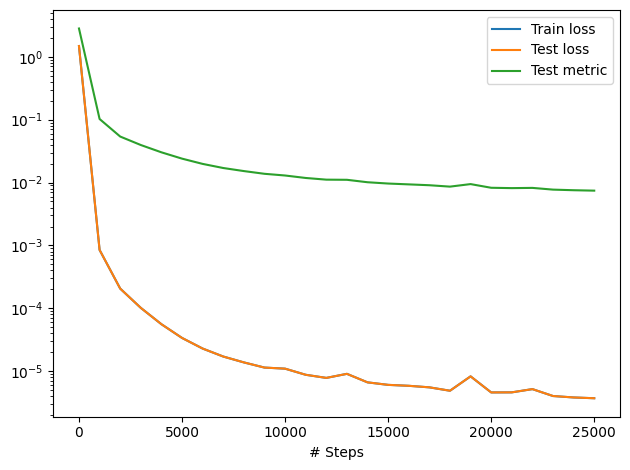

In [10]:
import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np

# Dataset
d = np.load("/content/antiderivative_aligned_train.npz", allow_pickle=True)
X_train = (d["X"][0].astype(np.float32), d["X"][1].astype(np.float32))
y_train = d["y"].astype(np.float32)

d = np.load("/content/antiderivative_aligned_test.npz", allow_pickle=True)
X_test = (d["X"][0].astype(np.float32), d["X"][1].astype(np.float32))
y_test = d["y"].astype(np.float32)

# Verificación de Dimensiones
# CartesianProd:
#   X[0] → (N_funciones, m_sensores)   : Funciones U evaluadas en sensores
#   X[1] → (P_puntos,    dim_x)        : Puntos de evaluación Y (Compartidos)
#   y    → (N_funciones, P_puntos)     : Valores de la Antiderivada
print("=" * 55)
print("  ESTRUCTURA DEL DATASET")
print("=" * 55)
print(f"  Branch input (train): {X_train[0].shape}")
print(f"  Trunk  input (train): {X_train[1].shape}")
print(f"  Output       (train): {y_train.shape}")
print(f"  Branch input (test):  {X_test[0].shape}")
print(f"  Trunk  input (test):  {X_test[1].shape}")
print(f"  Output       (test):  {y_test.shape}")
print("=" * 55)

data = dde.data.TripleCartesianProd(
    X_train=X_train, y_train=y_train,
    X_test=X_test,   y_test=y_test,
)

# Instanciación de Red
m     = X_train[0].shape[1]   # sensores (100)
dim_x = X_train[1].shape[1]   # dimensión de y (1)

net = dde.nn.DeepONetCartesianProd(
    [m, 64, 64],            # Branch: 100 → 64 → 64
    [dim_x, 64, 64],        # Trunk:    1 → 64 → 64
    "relu",                 # Activación
    "Glorot normal",        # Inicialización
)

# Comppilación y Entrenamiento
model = dde.Model(data, net)
model.compile("adam", lr=1e-4, metrics=["mean l2 relative error"])
losshistory, train_state = model.train(iterations=25000)

# Curva de Costo
dde.utils.plot_loss_history(losshistory)
plt.tight_layout()
plt.savefig("deeponet_loss.png", dpi=150, bbox_inches="tight")
plt.show()

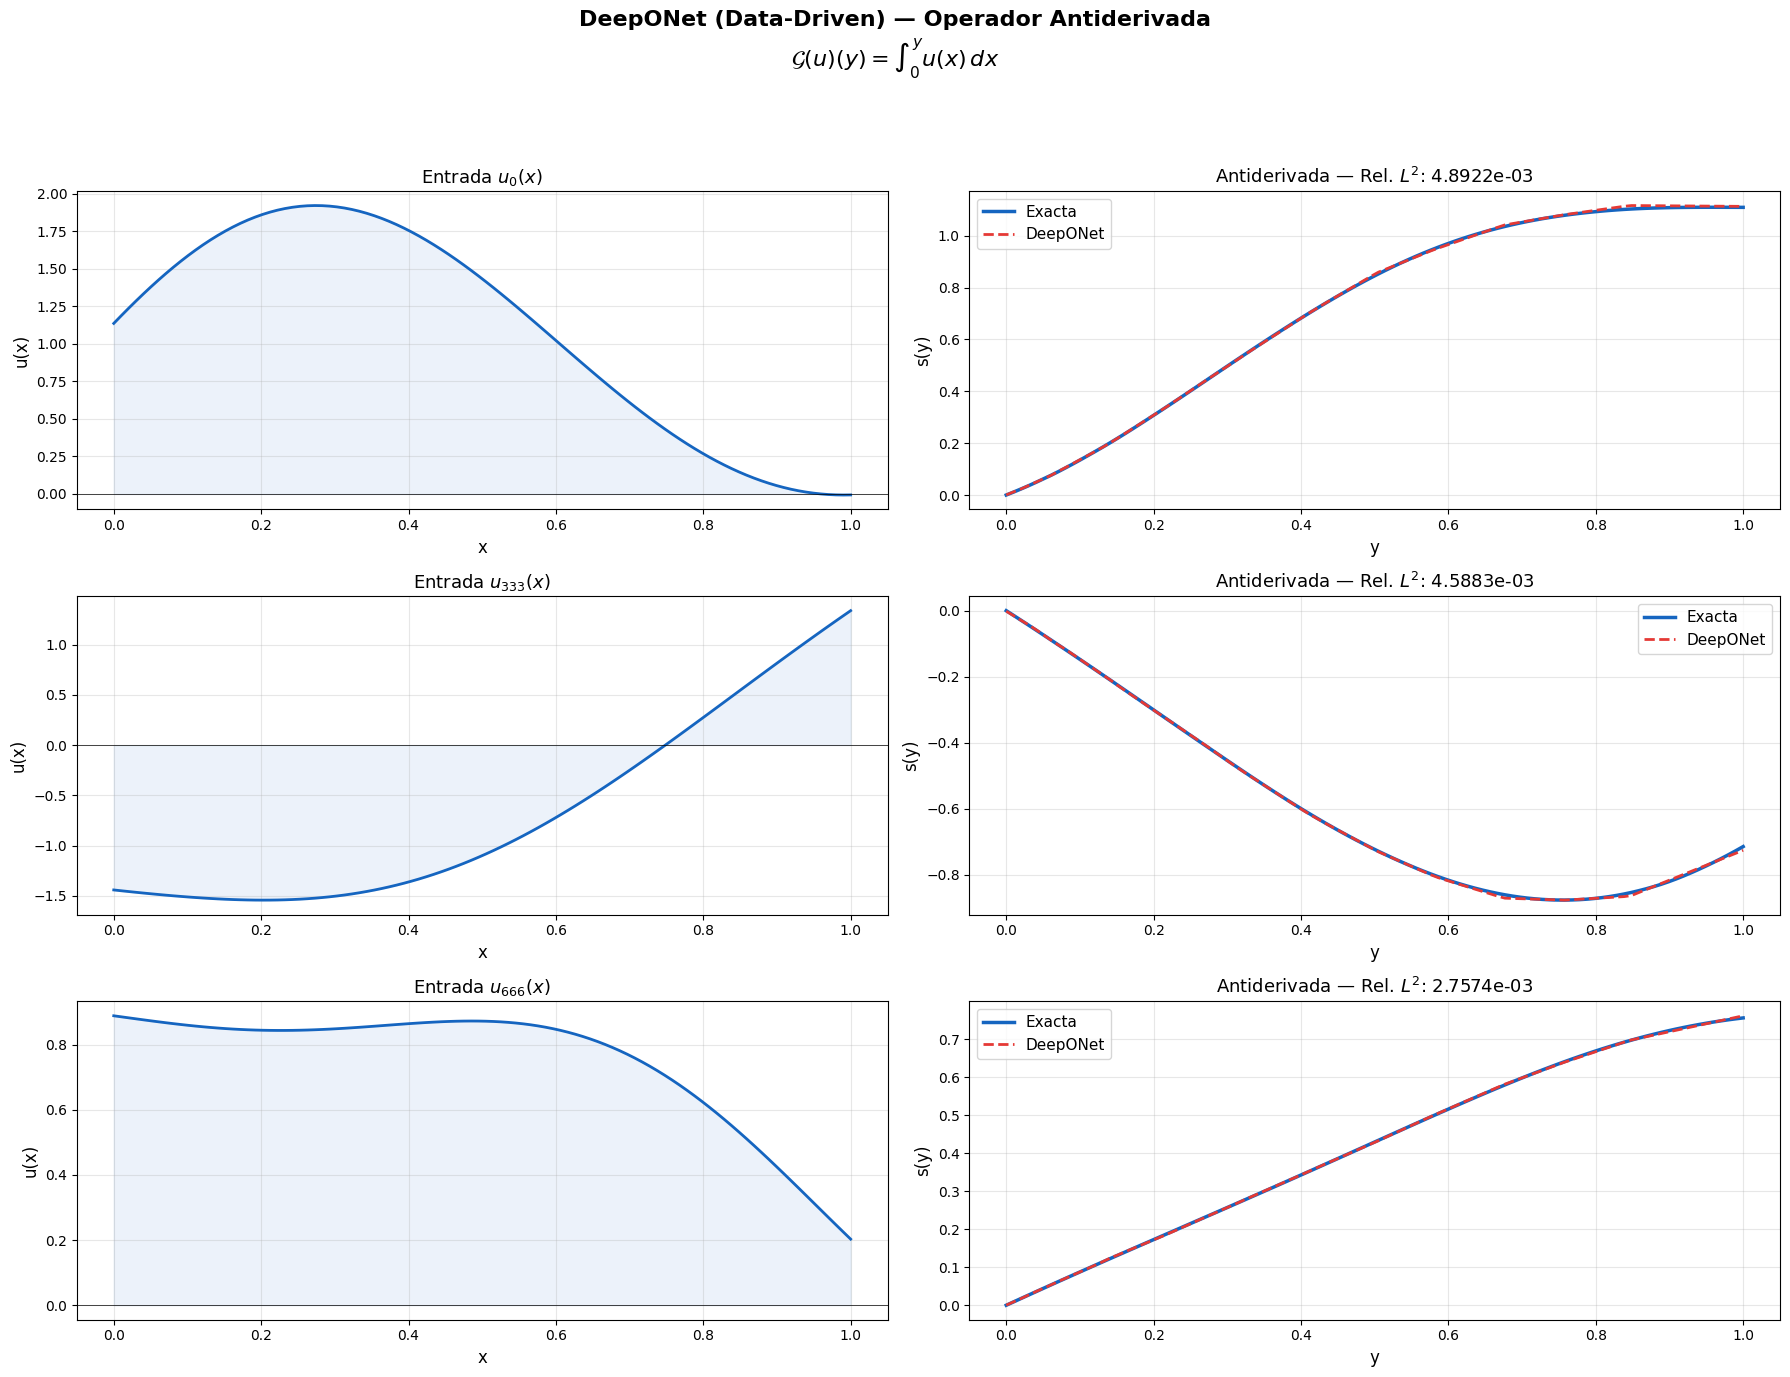


   MÉTRICAS GLOBALES — DeepONet (Data-Driven)
  MSE global:              3.721754e-06
  MAE global:              1.345633e-03
  Mean  Rel. L² Error:     7.434658e-03
  Median Rel. L² Error:    4.584664e-03
  Max   Rel. L² Error:     1.599443e-01
  Std   Rel. L² Error:     9.805758e-03


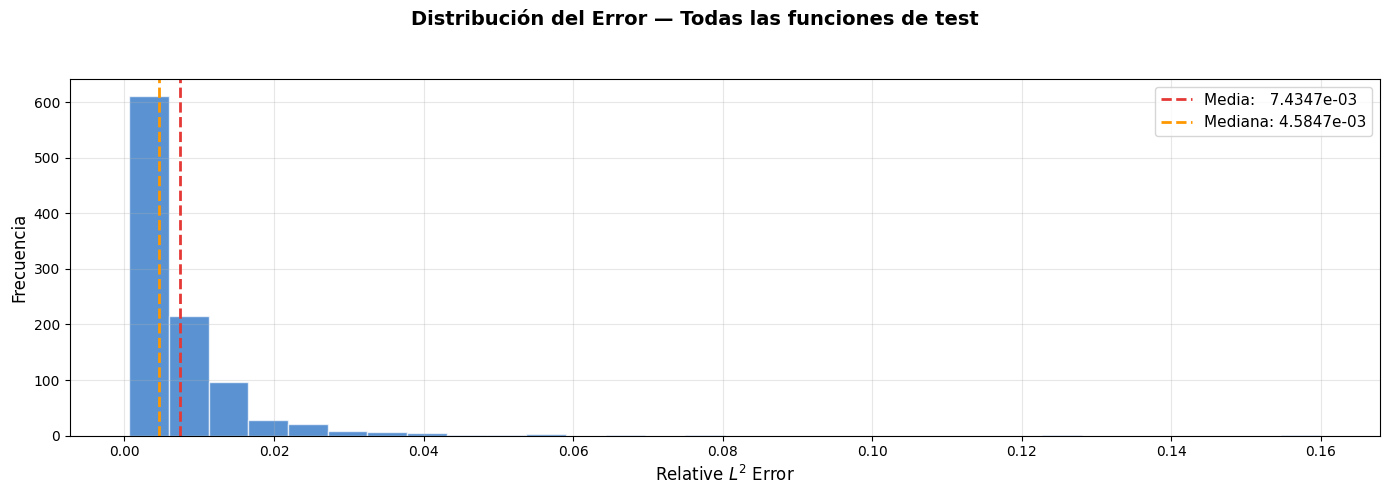

Output (test): (1000, 100)


In [11]:
# Predicciones
y_pred = model.predict(X_test)
y_pred = y_pred.reshape(y_test.shape)   # (N_test, P)

N_test = X_test[0].shape[0]            # Número de Funciones de Prueba
P      = X_test[1].shape[0]            # Número de Puntos de Evaluación

# Coordenadas
x_sensors = np.linspace(0, 1, m)       # Puntos Sensor para U(x)
y_eval    = X_test[1].flatten()        # Puntos Y de Evaluación

# Ordenar por Y para gráficas limpias
sort_idx = np.argsort(y_eval)
y_sorted = y_eval[sort_idx]

# Visualización de Predicciones
# Elegimos 3 funciones de test espaciadas
indices = [0, N_test // 3, 2 * N_test // 3]

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle(
    "DeepONet (Data-Driven) — Operador Antiderivada\n"
    r"$\mathcal{G}(u)(y) = \int_0^y u(x)\,dx$",
    fontsize=16, fontweight="bold",
)

for row, idx in enumerate(indices):

    # Datos por Instancia
    u_in    = X_test[0][idx]                # Función de Entrada
    s_true  = y_test[idx][sort_idx]         # Antiderivada Exacta (ordenada)
    s_pred  = y_pred[idx][sort_idx]         # Predicción de la Red (ordenada)

    # Métricas
    abs_err = np.abs(s_true - s_pred)
    rel_l2  = np.linalg.norm(s_true - s_pred) / (np.linalg.norm(s_true) + 1e-10)
    max_err = np.max(abs_err)
    mae_i   = np.mean(abs_err)

    # ---- Columna 1: Función de Entrada U(x) ----
    axes[row, 0].plot(x_sensors, u_in, "-", lw=2, color="#1565C0")
    axes[row, 0].fill_between(x_sensors, u_in, alpha=0.08, color="#1565C0")
    axes[row, 0].axhline(0, color="k", lw=0.5)
    axes[row, 0].set_xlabel("x", fontsize=12)
    axes[row, 0].set_ylabel("u(x)", fontsize=12)
    axes[row, 0].set_title(rf"Entrada $u_{{{idx}}}(x)$", fontsize=13)
    axes[row, 0].grid(True, alpha=0.3)

    # ---- Columna 2: Antiderivada Exacta vs Predicción ----
    axes[row, 1].plot(y_sorted, s_true, "-",  lw=2.5, color="#1565C0",
                      label="Exacta")
    axes[row, 1].plot(y_sorted, s_pred, "--", lw=2,   color="#E53935",
                      label="DeepONet")
    axes[row, 1].set_xlabel("y", fontsize=12)
    axes[row, 1].set_ylabel("s(y)", fontsize=12)
    axes[row, 1].set_title(
        rf"Antiderivada — Rel. $L^2$: {rel_l2:.4e}", fontsize=13
    )
    axes[row, 1].legend(fontsize=11)
    axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("deeponet_3instancias.png", dpi=150, bbox_inches="tight")
plt.show()

# Métricas Globales
rel_l2_all = np.array([
    np.linalg.norm(y_test[i] - y_pred[i]) /
    (np.linalg.norm(y_test[i]) + 1e-10)
    for i in range(N_test)
])

mse_global = np.mean((y_test - y_pred) ** 2)
mae_global = np.mean(np.abs(y_test - y_pred))
r2_global  = 1.0 - (
    np.sum((y_test - y_pred) ** 2) /
    np.sum((y_test - np.mean(y_test)) ** 2)
)

print("\n" + "=" * 55)
print("   MÉTRICAS GLOBALES — DeepONet (Data-Driven)")
print("=" * 55)
print(f"  MSE global:              {mse_global:.6e}")
print(f"  MAE global:              {mae_global:.6e}")
print(f"  Mean  Rel. L² Error:     {np.mean(rel_l2_all):.6e}")
print(f"  Median Rel. L² Error:    {np.median(rel_l2_all):.6e}")
print(f"  Max   Rel. L² Error:     {np.max(rel_l2_all):.6e}")
print(f"  Std   Rel. L² Error:     {np.std(rel_l2_all):.6e}")
print("=" * 55)


# Distribución de Error
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
fig.suptitle(
    "Distribución del Error — Todas las funciones de test",
    fontsize=14, fontweight="bold",
)

# Histograma
ax.hist(rel_l2_all, bins=30, color="#1565C0", alpha=0.7,
        edgecolor="white")
ax.axvline(np.mean(rel_l2_all),   color="#E53935", ls="--", lw=2,
           label=f"Media:   {np.mean(rel_l2_all):.4e}")
ax.axvline(np.median(rel_l2_all), color="#FF9800", ls="--", lw=2,
           label=f"Mediana: {np.median(rel_l2_all):.4e}")
ax.set_xlabel(r"Relative $L^2$ Error", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("deeponet_distribucion_error.png", dpi=150, bbox_inches="tight")
plt.show()


print(f"Output (test): {y_test.shape}")


   VERIFICACIÓN ANALÍTICA — DeepONet (Data-Driven)
                    Función |       Rel L² |      Máx |e| |          MAE
-----------------------------------------------------------------
       $u(x) = \sin(\pi x)$ |   9.8521e-03 |   6.3494e-03 |   3.5087e-03
               $u(x) = x^2$ |   1.7291e-02 |   9.7753e-03 |   1.5368e-03
               $u(x) = e^x$ |   5.1909e-03 |   1.4286e-02 |   3.3757e-03
      $u(x) = \cos(2\pi x)$ |   1.2252e-01 |   2.1062e-02 |   1.2426e-02


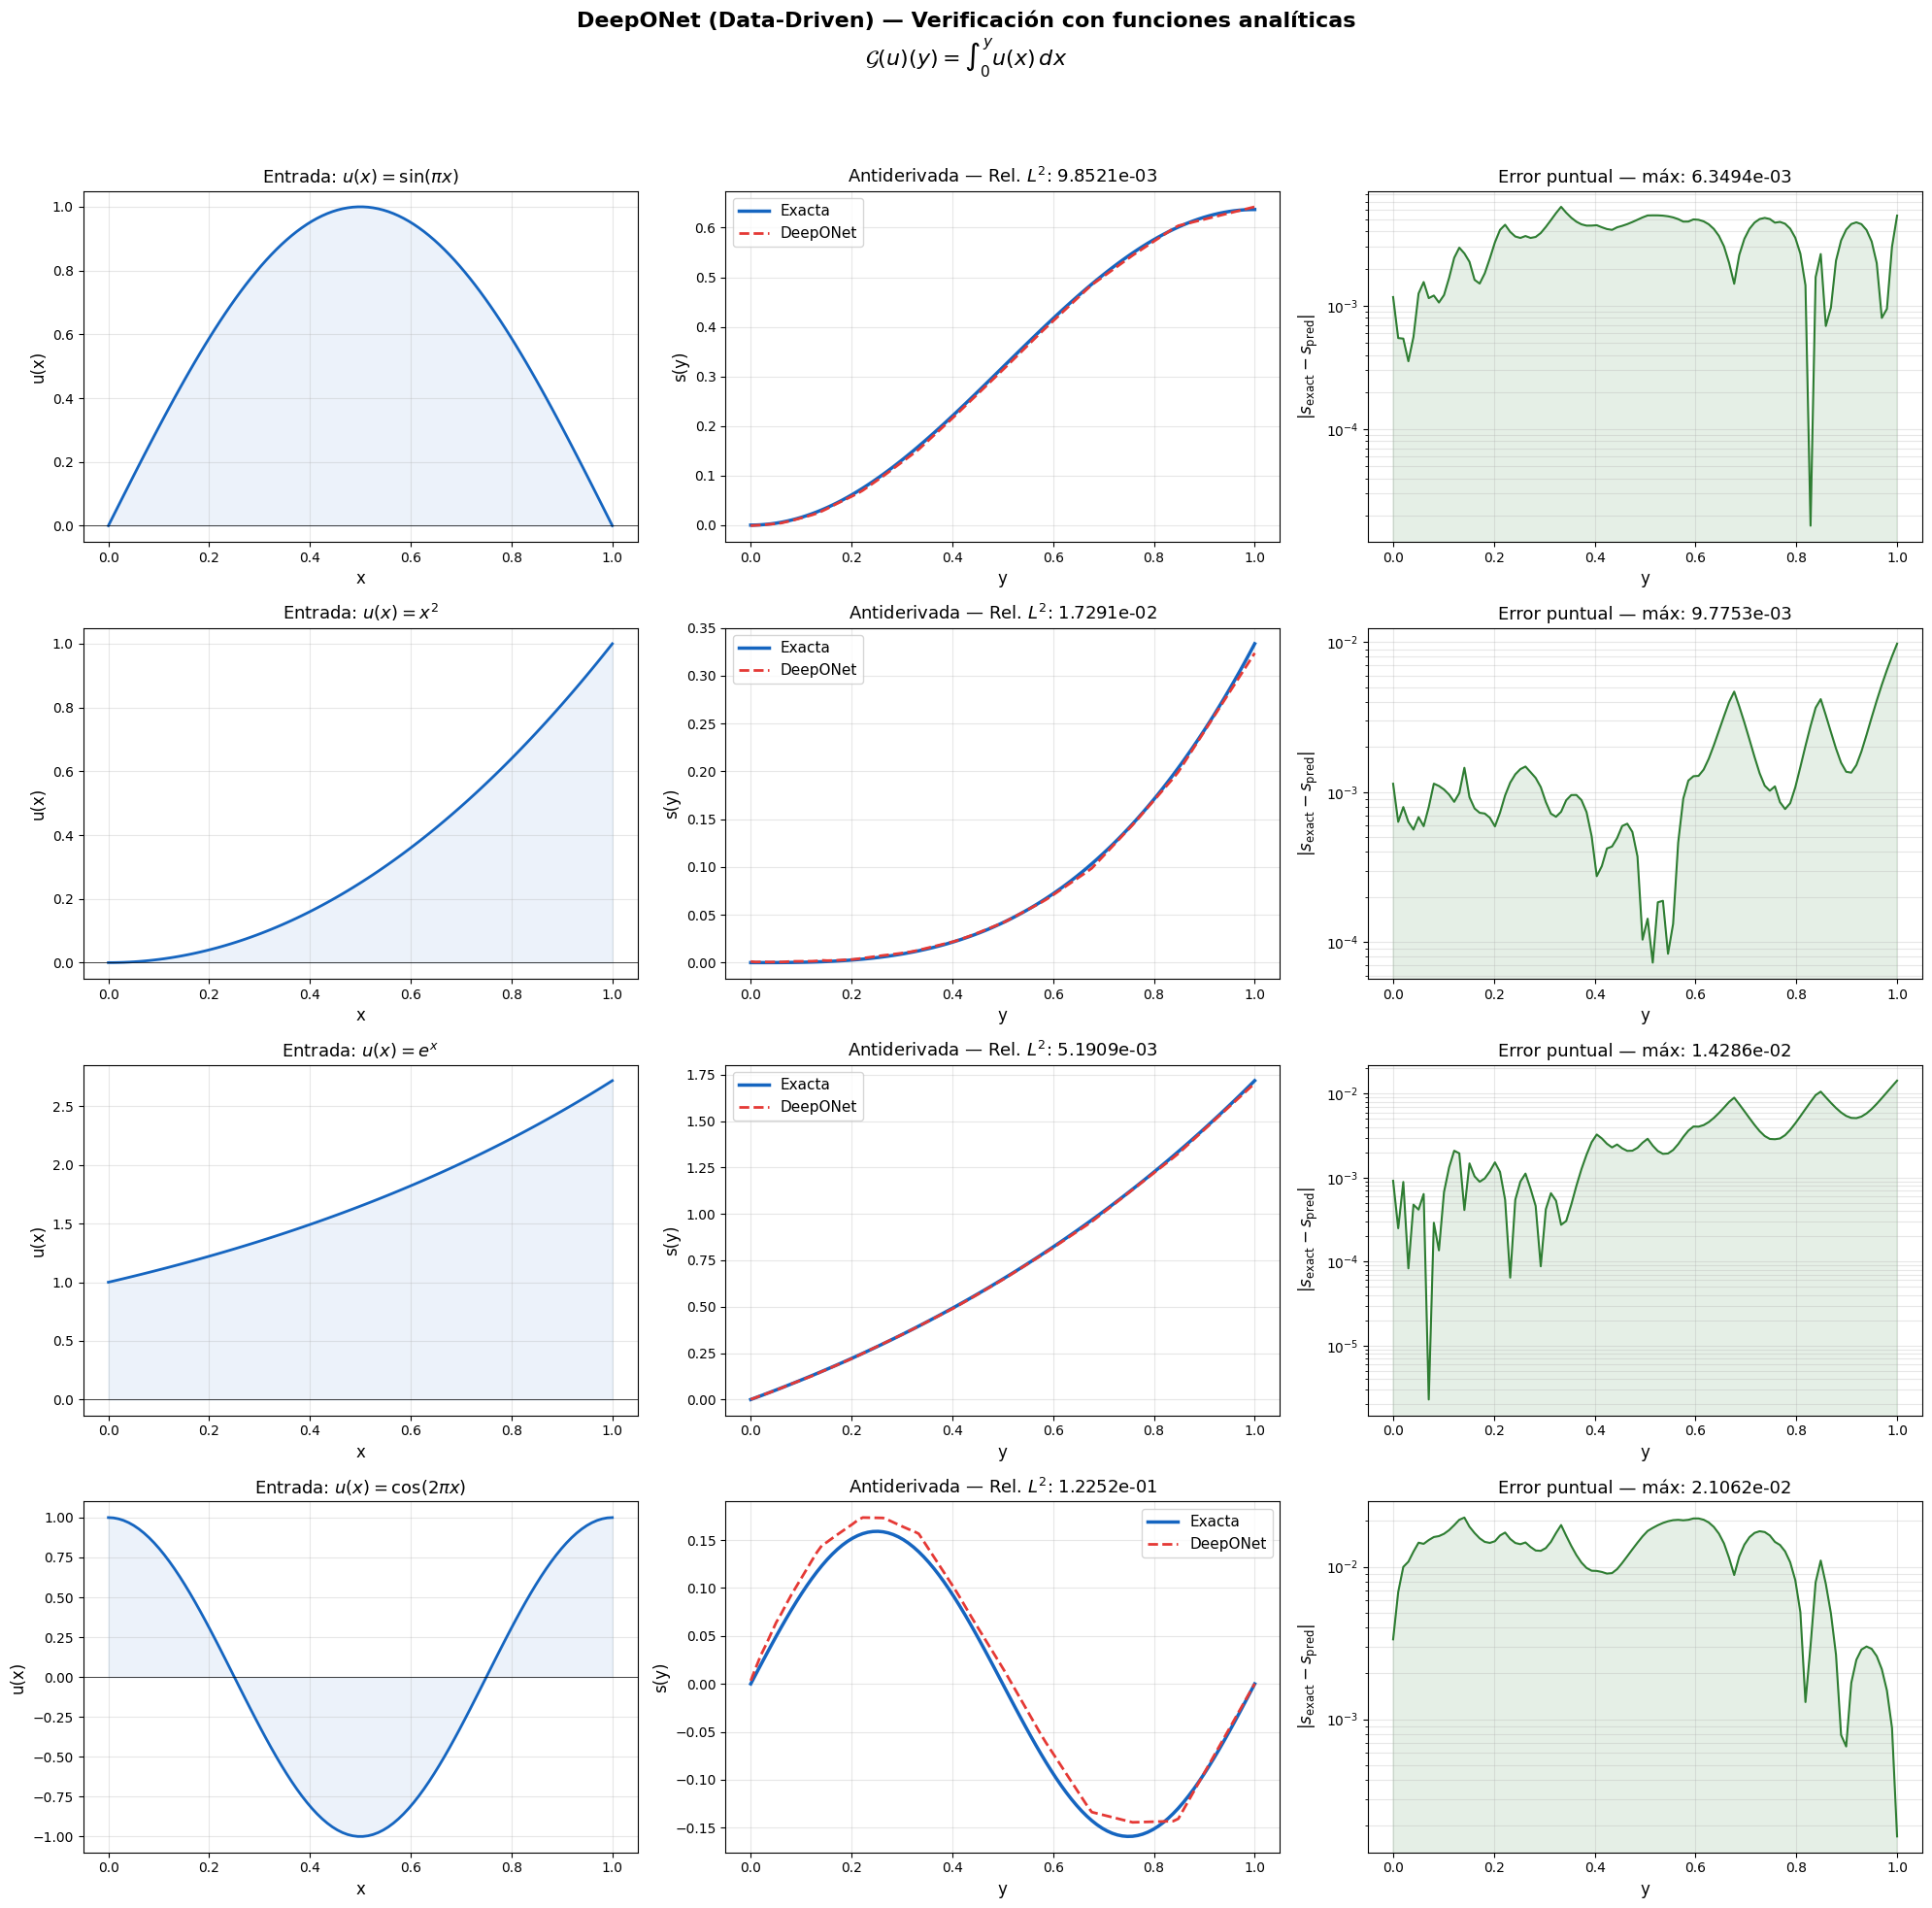

In [12]:
# Definición de funciones analíticas y sus antiderivadas
analytic_cases = {
    r"$u(x) = \sin(\pi x)$": {
        "u":      lambda x: np.sin(np.pi * x),
        "s_true": lambda y: (1.0 - np.cos(np.pi * y)) / np.pi,
    },
    r"$u(x) = x^2$": {
        "u":      lambda x: x ** 2,
        "s_true": lambda y: y ** 3 / 3.0,
    },
    r"$u(x) = e^x$": {
        "u":      lambda x: np.exp(x),
        "s_true": lambda y: np.exp(y) - 1.0,
    },
    r"$u(x) = \cos(2\pi x)$": {
        "u":      lambda x: np.cos(2.0 * np.pi * x),
        "s_true": lambda y: np.sin(2.0 * np.pi * y) / (2.0 * np.pi),
    },
}

# Puntos de evaluación (misma grilla que el trunk)
# Para CartesianProd: trunk = X_test[1] con shape (P, 1)
trunk_pts = X_test[1]                        # (P, 1)
y_coords  = trunk_pts.flatten()              # (P,)
sort_a    = np.argsort(y_coords)
y_sort    = y_coords[sort_a]

# Sensores de la branch
x_sens = np.linspace(0, 1, m)                # (m,)

# ---- Figura 4×3: cada fila = 1 función analítica ----
n_cases = len(analytic_cases)
fig, axes = plt.subplots(n_cases, 3, figsize=(20, 5 * n_cases))
fig.suptitle(
    "DeepONet (Data-Driven) — Verificación con funciones analíticas\n"
    r"$\mathcal{G}(u)(y) = \int_0^y u(x)\,dx$",
    fontsize=16, fontweight="bold",
)

print("\n" + "=" * 65)
print("   VERIFICACIÓN ANALÍTICA — DeepONet (Data-Driven)")
print("=" * 65)
print(f"  {'Función':>25s} | {'Rel L²':>12s} | "
      f"{'Máx |e|':>12s} | {'MAE':>12s}")
print("-" * 65)

for row, (label, case) in enumerate(analytic_cases.items()):

    # Evaluar u en sensores → entrada del branch (1, m)
    u_vals  = case["u"](x_sens).astype(np.float32)
    v_input = u_vals.reshape(1, -1)

    # Predicción del modelo
    s_pred_raw = model.predict((v_input, trunk_pts))   # (1, P)
    s_pred_a   = s_pred_raw.flatten()[sort_a]

    # Solución exacta
    s_exact_a = case["s_true"](y_sort)

    # Métricas
    abs_err = np.abs(s_exact_a - s_pred_a)
    rel_l2  = (np.linalg.norm(s_exact_a - s_pred_a)
               / (np.linalg.norm(s_exact_a) + 1e-10))
    max_err = np.max(abs_err)
    mae_val = np.mean(abs_err)

    print(f"  {label:>25s} | {rel_l2:>12.4e} | "
          f"{max_err:>12.4e} | {mae_val:>12.4e}")

    # ---- Col 1: función de entrada u(x) ----
    axes[row, 0].plot(x_sens, u_vals, "-", lw=2, color="#1565C0")
    axes[row, 0].fill_between(x_sens, u_vals, alpha=0.08,
                              color="#1565C0")
    axes[row, 0].axhline(0, color="k", lw=0.5)
    axes[row, 0].set_xlabel("x", fontsize=12)
    axes[row, 0].set_ylabel("u(x)", fontsize=12)
    axes[row, 0].set_title(f"Entrada: {label}", fontsize=13)
    axes[row, 0].grid(True, alpha=0.3)

    # ---- Col 2: antiderivada exacta vs predicción ----
    axes[row, 1].plot(y_sort, s_exact_a, "-",  lw=2.5,
                      color="#1565C0", label="Exacta")
    axes[row, 1].plot(y_sort, s_pred_a,  "--", lw=2,
                      color="#E53935",  label="DeepONet")
    axes[row, 1].set_xlabel("y", fontsize=12)
    axes[row, 1].set_ylabel("s(y)", fontsize=12)
    axes[row, 1].set_title(
        rf"Antiderivada — Rel. $L^2$: {rel_l2:.4e}", fontsize=13
    )
    axes[row, 1].legend(fontsize=11)
    axes[row, 1].grid(True, alpha=0.3)

    # ---- Col 3: error puntual (escala log) ----
    axes[row, 2].semilogy(y_sort, abs_err + 1e-16, "-", lw=1.5,
                          color="#2E7D32")
    axes[row, 2].fill_between(y_sort, abs_err + 1e-16, alpha=0.12,
                              color="#2E7D32")
    axes[row, 2].set_xlabel("y", fontsize=12)
    axes[row, 2].set_ylabel(r"$|s_{\rm exact} - s_{\rm pred}|$",
                            fontsize=12)
    axes[row, 2].set_title(
        f"Error puntual — máx: {max_err:.4e}", fontsize=13
    )
    axes[row, 2].grid(True, alpha=0.3, which="both")

print("=" * 65)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("deeponet_analiticas.png", dpi=150, bbox_inches="tight")
plt.show()

# **DeepONet - Physics Loss Approach**

Disable just-in-time compilation with XLA.


Compiling model...
'compile' took 0.006753 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7c0dbd310fe0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7c0dbd310fe0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss              Test loss               Test metric
0         [2.01e+00, 0.00e+00]    [2.67e+00, 0.00e+00]    []  
1000      [1.61e-01, 0.00e+00]    [1.49e-01, 0.00e+00]    []  
2000      [7.72e-02, 0.00e+00]    [6.36e-02, 0.00e+00]    []  
3000      [6.03e-02, 0.00e+00]    [4.38e-02, 0.00e+00]    []  
4000      [1.49e-02, 0.00e+00]    [1.51e-02, 0.00e+00]    []  
5000      [1.10e-02, 0.00e+00]    [9.81e-03, 0.00e+00]    []  
6000      [6.54e-03, 0.00e+00]    [6.37e-03, 0.00e+00]    []  
7000 

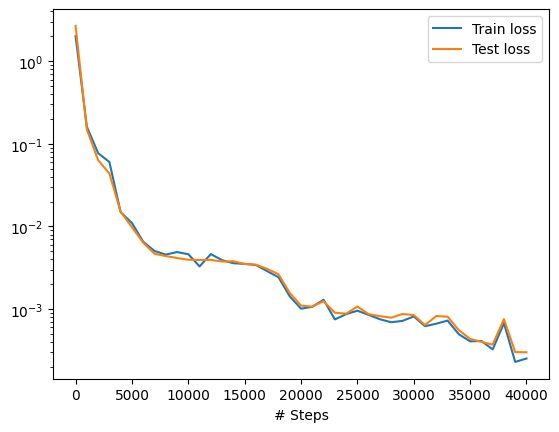

In [13]:
import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import cumulative_trapezoid

# Backend Config
if dde.backend.backend_name == "paddle":
    import paddle
    transpose = paddle.transpose
elif dde.backend.backend_name == "pytorch":
    import torch
    transpose = lambda x, y: torch.transpose(x, y[0], y[1])
else:
    from deepxde.backend import tf
    transpose = tf.transpose

dde.config.disable_xla_jit()

# Definición de la Física: PDE, Fronteras, ICs
geom = dde.geometry.TimeDomain(0, 1)

def pde(x, u, v):
    # La física: du/dx - v(x) = 0
    return dde.grad.jacobian(u, x) - v

ic = dde.icbc.IC(geom, lambda _: 0, lambda _, on_initial: on_initial)
pde_obj = dde.data.PDE(geom, pde, ic, num_domain=20, num_boundary=2, num_test=40)

# Espacio de Funciones para Generar v(x)
func_space = dde.data.GRF(length_scale=0.2)

# Generación de Puntos de Colocación
eval_pts = np.linspace(0, 1, num=50)[:, None]
data = dde.data.PDEOperatorCartesianProd(
    pde_obj, func_space, eval_pts, 1000, num_test=100, batch_size=100
)

# Instanciación de Red
net = dde.nn.DeepONetCartesianProd(
    [50, 128, 128, 128],
    [1, 128, 128, 128],
    "tanh",
    "Glorot normal",
)

# Hard Constraint para u(0) = 0
def zero_ic(inputs, outputs):
    return outputs * transpose(inputs[1], [1, 0])

net.apply_output_transform(zero_ic)

# Entrenamiento
model = dde.Model(data, net)
model.compile("adam", lr=1e-4)
losshistory, train_state = model.train(iterations=40000)

dde.utils.plot_loss_history(losshistory)
plt.savefig("pideeponet_loss.png", dpi=150, bbox_inches="tight")
plt.show()

  DIAGNÓSTICO DE DIMENSIONES
  data.test_x[0]:  (100, 50)  (funciones v)
  data.test_x[1]:  (41, 1)  (puntos PDE ≠ eval_pts!)
  eval_pts:        (50, 1)        (nuestros 50 puntos)
  → Usamos eval_pts, NO data.test_x[1]
  y_test:  (100, 50)
  y_pred:  (100, 50)
  ✓ Shapes coinciden


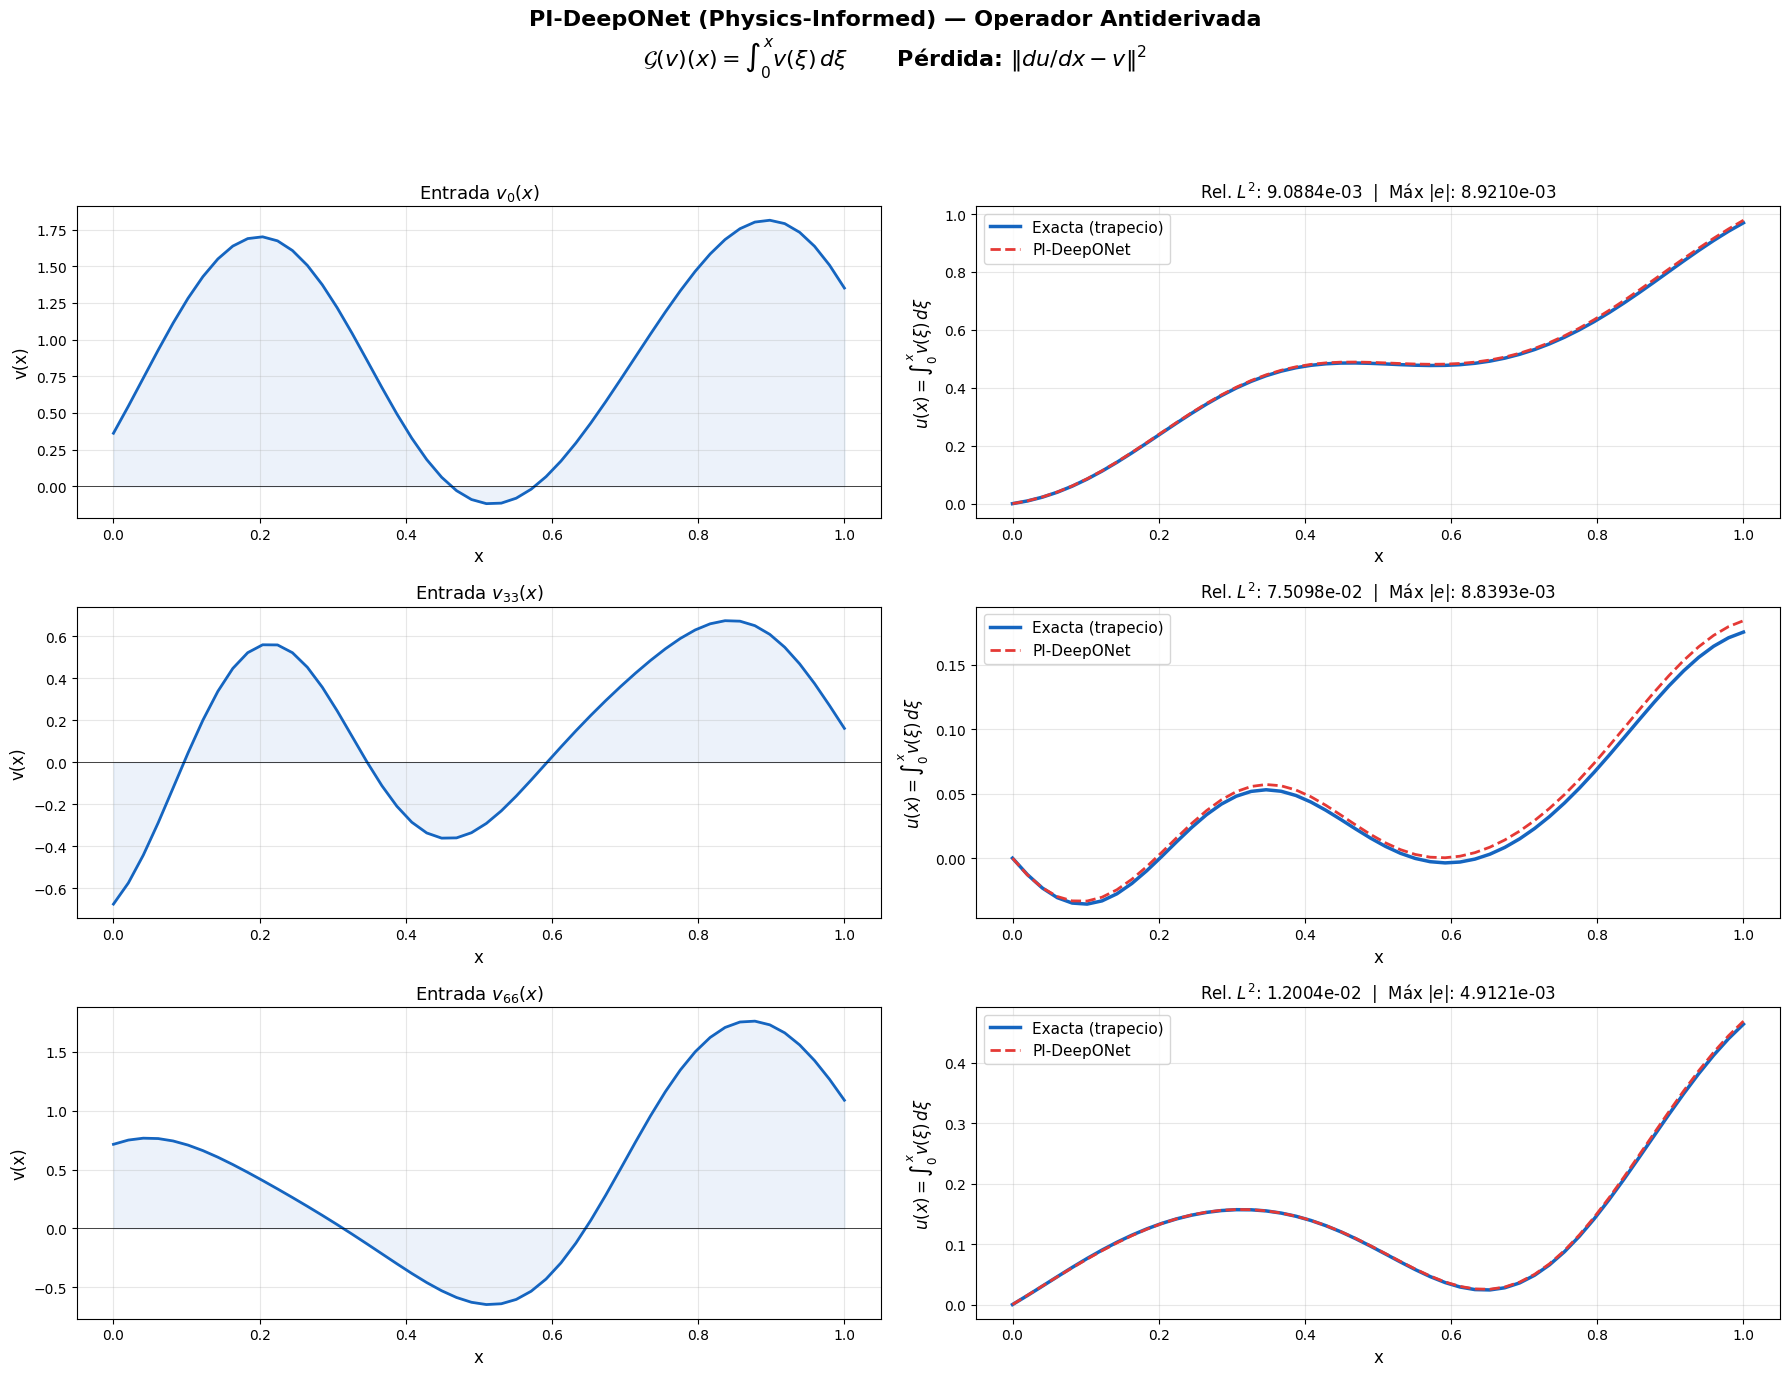


   MÉTRICAS GLOBALES — PI-DeepONet
  MSE global:              1.202555e-05
  MAE global:              2.401460e-03
  Mean  Rel. L² Error:     1.204631e-02
  Median Rel. L² Error:    7.530930e-03
  Max   Rel. L² Error:     9.778435e-02
  Std   Rel. L² Error:     1.395177e-02

   Instancia |       Rel L² |      Máx |e| |          MAE
-------------------------------------------------------
  v_0       |   9.0884e-03 |   8.9210e-03 |   3.9870e-03
  v_33      |   7.5098e-02 |   8.8393e-03 |   4.5418e-03
  v_66      |   1.2004e-02 |   4.9121e-03 |   1.4712e-03


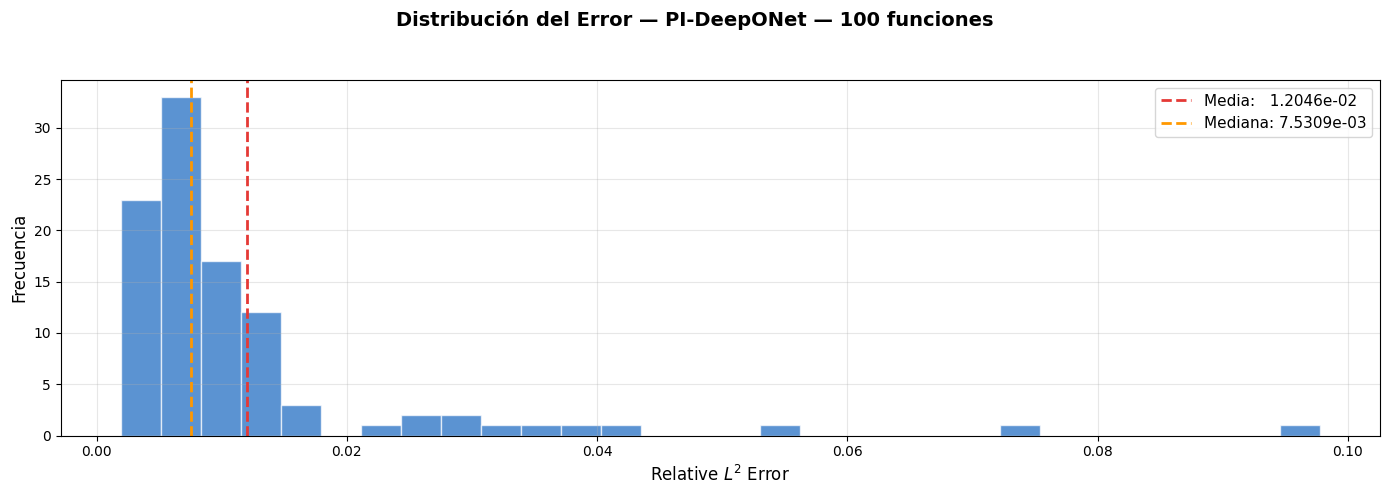


   VERIFICACIÓN ANALÍTICA — PI-DeepONet
               Función |       Rel L² |      Máx |e| |          MAE
-----------------------------------------------------------------
         $\sin(\pi x)$ |   1.0416e-03 |   7.1075e-04 |   3.6011e-04
                 $x^2$ |   5.6366e-03 |   1.1699e-03 |   6.3088e-04
                 $e^x$ |   2.8067e-03 |   3.8755e-03 |   2.2968e-03
        $\cos(2\pi x)$ |   3.3187e-03 |   7.6287e-04 |   3.0608e-04


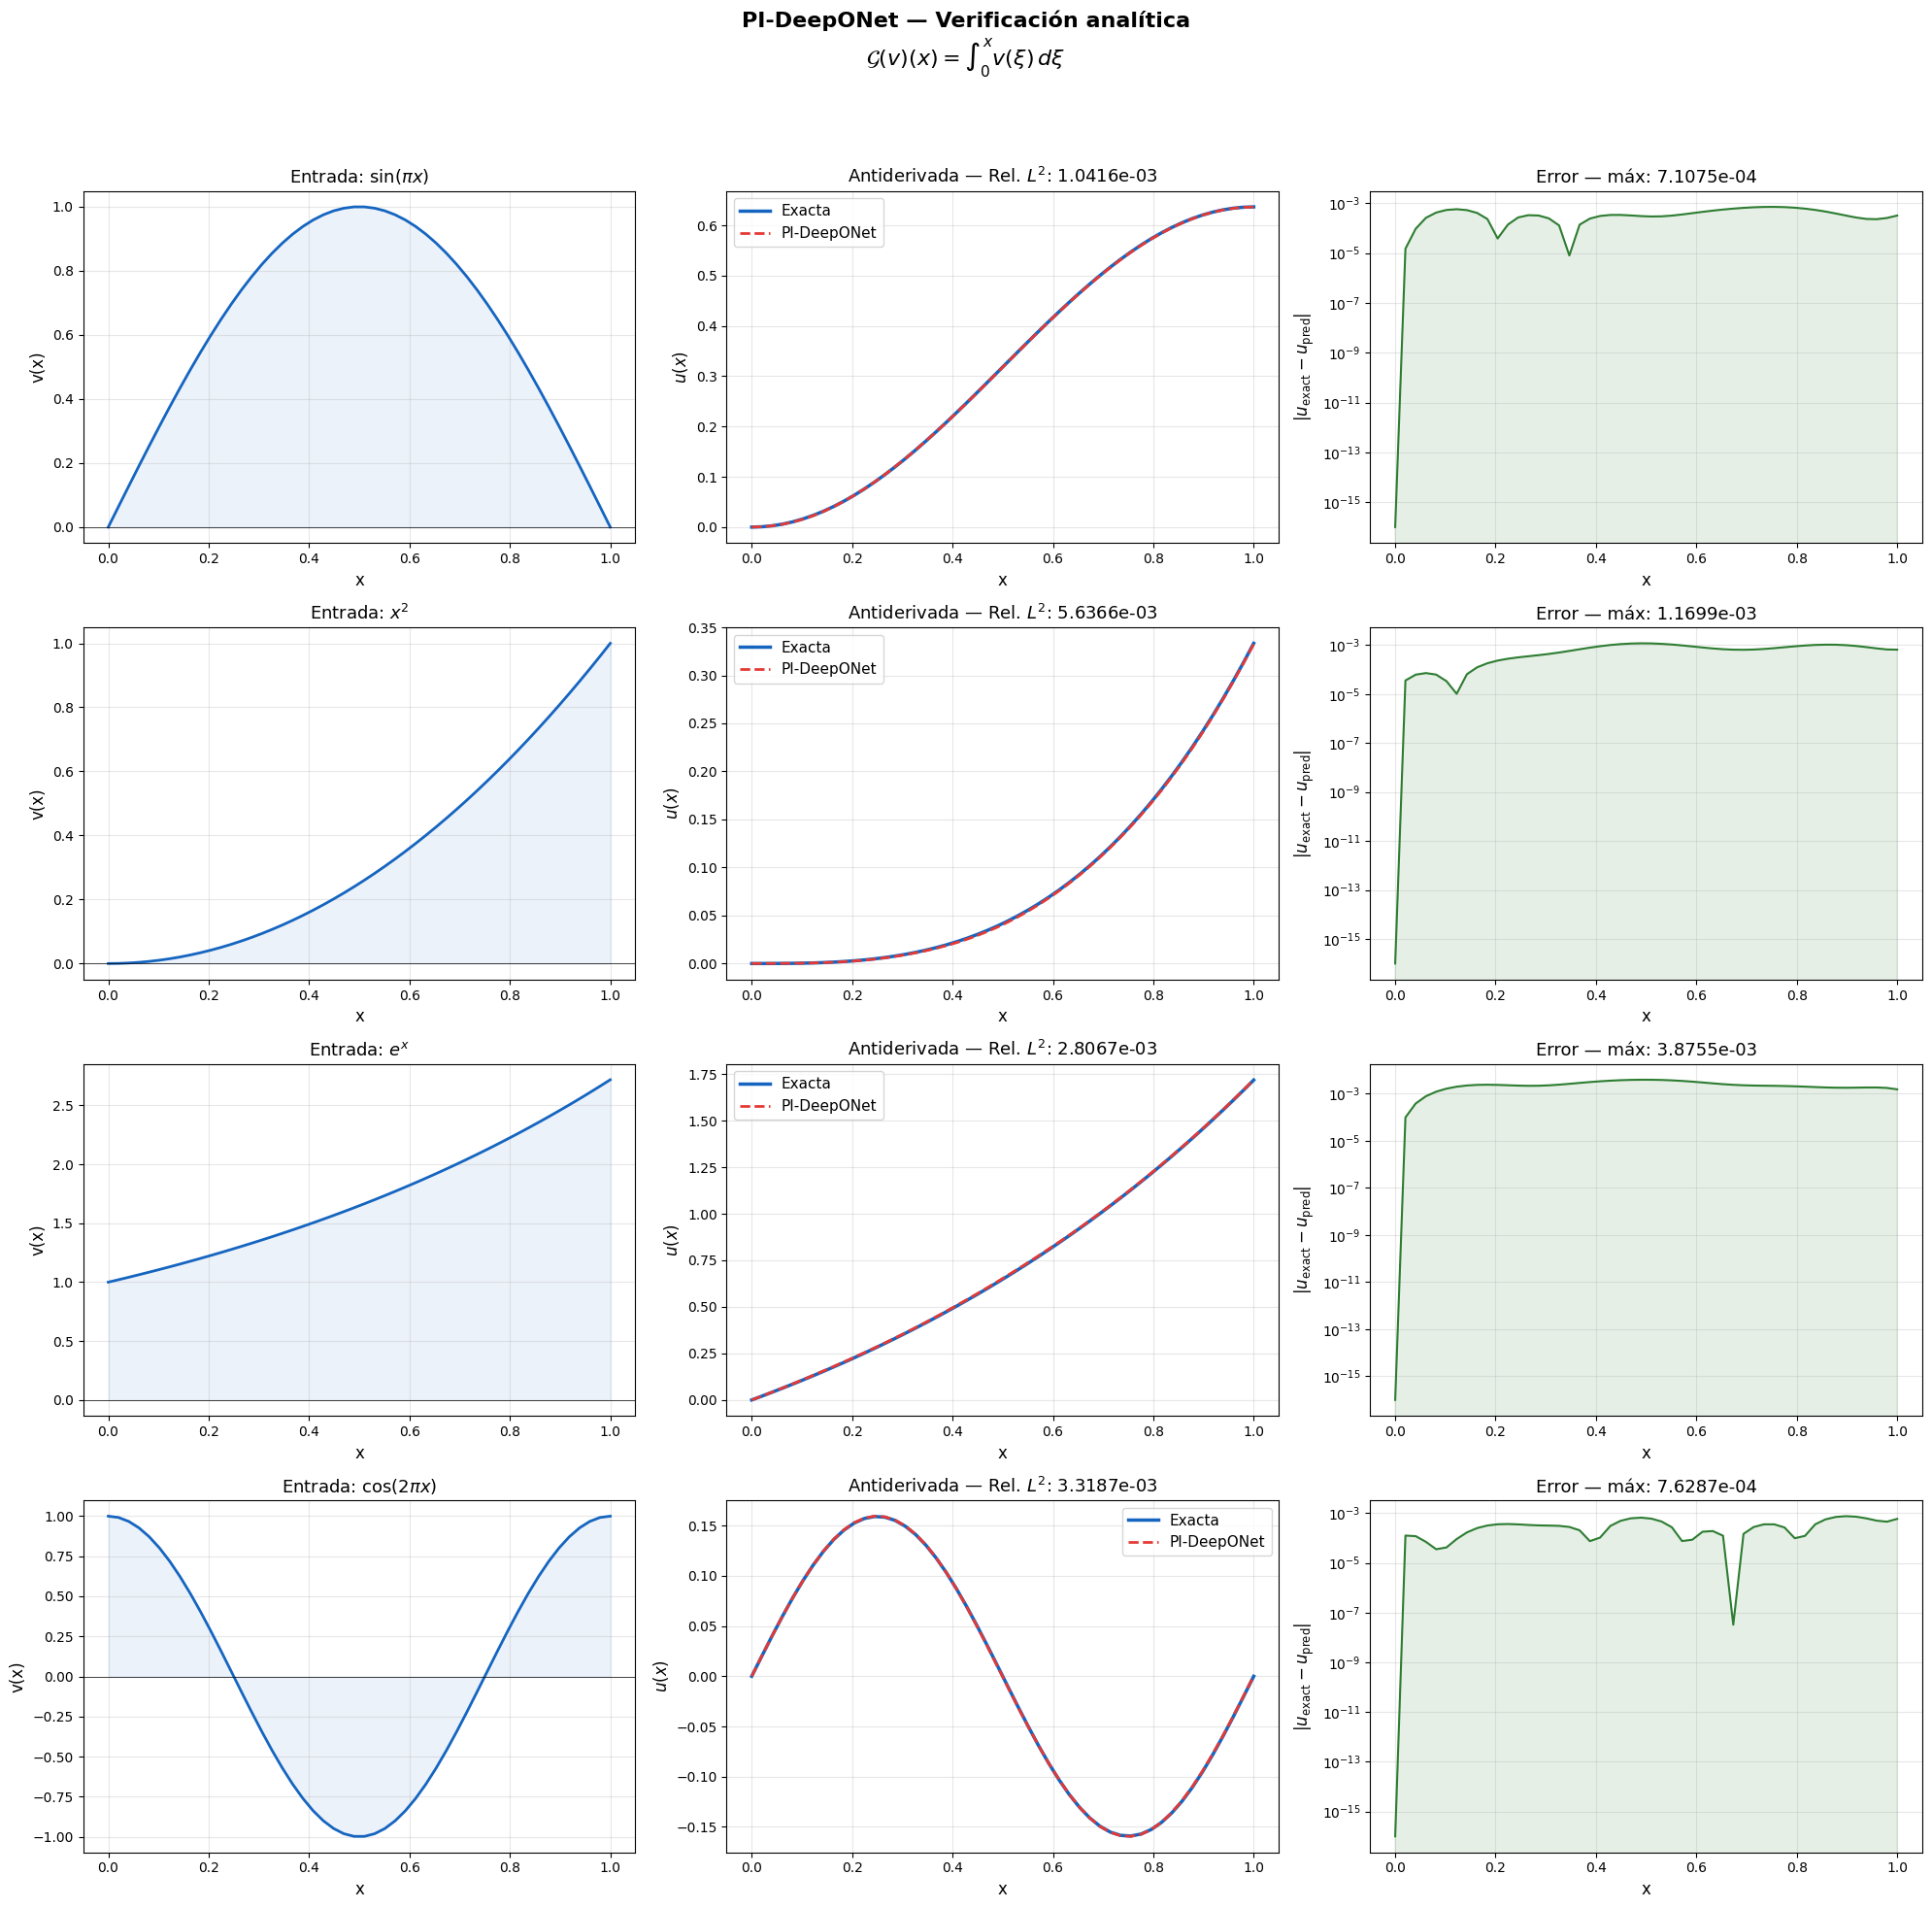

In [22]:
# ============================================================
# EVALUACIÓN DEL PI-DeepONet ENTRENADO
# ============================================================
from scipy.integrate import cumulative_trapezoid

# ------------------------------------------------------------
# 1. EXTRAER FUNCIONES DE TEST Y DEFINIR GRILLA DE EVALUACIÓN
# ------------------------------------------------------------
# Las funciones v(x) sí están bien en data.test_x[0]
# Pero data.test_x[1] NO es eval_pts — son puntos internos de la PDE

v_test  = data.test_x[0]                   # (100, 50) ✓ correcto
x_coord = eval_pts.flatten()               # (50,)     usamos eval_pts directamente

N_test = v_test.shape[0]                   # 100
P      = x_coord.shape[0]                  # 50
m      = P                                 # 50

# Verificación
print("=" * 55)
print("  DIAGNÓSTICO DE DIMENSIONES")
print("=" * 55)
print(f"  data.test_x[0]:  {data.test_x[0].shape}  (funciones v)")
print(f"  data.test_x[1]:  {data.test_x[1].shape}  (puntos PDE ≠ eval_pts!)")
print(f"  eval_pts:        {eval_pts.shape}        (nuestros 50 puntos)")
print(f"  → Usamos eval_pts, NO data.test_x[1]")
print("=" * 55)

# ------------------------------------------------------------
# 2. GROUND TRUTH: INTEGRACIÓN NUMÉRICA
# ------------------------------------------------------------
y_test = cumulative_trapezoid(
    v_test,         # (100, 50)
    x_coord,        # (50,)
    initial=0,      # u(0) = 0
    axis=1,         # integrar a lo largo de sensores
)                   # → (100, 50)

# ------------------------------------------------------------
# 3. PREDICCIÓN — CONSTRUIR ENTRADA MANUALMENTE
# ------------------------------------------------------------
# En vez de data.test_x, pasamos (v_test, eval_pts)
X_pred = (v_test.astype(np.float32), eval_pts.astype(np.float32))
y_pred = model.predict(X_pred)              # (100, 50)
y_pred = y_pred.reshape(N_test, P)

# Verificación
print(f"  y_test:  {y_test.shape}")
print(f"  y_pred:  {y_pred.shape}")
assert y_test.shape == y_pred.shape, \
    f"Shapes: {y_test.shape} vs {y_pred.shape}"
print("  ✓ Shapes coinciden")
print("=" * 55)

# ============================================================
# 4. VISUALIZACIÓN: 3 INSTANCIAS DE TEST
# ============================================================
indices = [0, N_test // 3, 2 * N_test // 3]

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle(
    "PI-DeepONet (Physics-Informed) — Operador Antiderivada\n"
    r"$\mathcal{G}(v)(x) = \int_0^x v(\xi)\,d\xi$"
    r"$\qquad$ Pérdida: $\|du/dx - v\|^2$",
    fontsize=16, fontweight="bold",
)

for row, idx in enumerate(indices):

    v_in   = v_test[idx]
    u_true = y_test[idx]
    u_pred = y_pred[idx]

    abs_err = np.abs(u_true - u_pred)
    rel_l2  = (np.linalg.norm(u_true - u_pred)
               / (np.linalg.norm(u_true) + 1e-10))
    max_err = np.max(abs_err)

    # Col 1: v(x)
    axes[row, 0].plot(x_coord, v_in, "-", lw=2, color="#1565C0")
    axes[row, 0].fill_between(x_coord, v_in, alpha=0.08, color="#1565C0")
    axes[row, 0].axhline(0, color="k", lw=0.5)
    axes[row, 0].set_xlabel("x", fontsize=12)
    axes[row, 0].set_ylabel("v(x)", fontsize=12)
    axes[row, 0].set_title(rf"Entrada $v_{{{idx}}}(x)$", fontsize=13)
    axes[row, 0].grid(True, alpha=0.3)

    # Col 2: u(x) exacta vs predicción
    axes[row, 1].plot(x_coord, u_true, "-",  lw=2.5, color="#1565C0",
                      label="Exacta (trapecio)")
    axes[row, 1].plot(x_coord, u_pred, "--", lw=2,   color="#E53935",
                      label="PI-DeepONet")
    axes[row, 1].set_xlabel("x", fontsize=12)
    axes[row, 1].set_ylabel(r"$u(x) = \int_0^x v(\xi)\,d\xi$",
                            fontsize=12)
    axes[row, 1].set_title(
        rf"Rel. $L^2$: {rel_l2:.4e}  |  "
        rf"Máx $|e|$: {max_err:.4e}", fontsize=12)
    axes[row, 1].legend(fontsize=11)
    axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("pideeponet_3instancias.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# 5. MÉTRICAS GLOBALES
# ============================================================
rel_l2_all = np.array([
    np.linalg.norm(y_test[i] - y_pred[i])
    / (np.linalg.norm(y_test[i]) + 1e-10)
    for i in range(N_test)
])

mse_global = np.mean((y_test - y_pred) ** 2)
mae_global = np.mean(np.abs(y_test - y_pred))

print("\n" + "=" * 55)
print("   MÉTRICAS GLOBALES — PI-DeepONet")
print("=" * 55)
print(f"  MSE global:              {mse_global:.6e}")
print(f"  MAE global:              {mae_global:.6e}")
print(f"  Mean  Rel. L² Error:     {np.mean(rel_l2_all):.6e}")
print(f"  Median Rel. L² Error:    {np.median(rel_l2_all):.6e}")
print(f"  Max   Rel. L² Error:     {np.max(rel_l2_all):.6e}")
print(f"  Std   Rel. L² Error:     {np.std(rel_l2_all):.6e}")
print("=" * 55)

# Tabla por instancia
print(f"\n{'Instancia':>12} | {'Rel L²':>12} | "
      f"{'Máx |e|':>12} | {'MAE':>12}")
print("-" * 55)
for idx in indices:
    r  = (np.linalg.norm(y_test[idx] - y_pred[idx])
          / (np.linalg.norm(y_test[idx]) + 1e-10))
    mx = np.max(np.abs(y_test[idx] - y_pred[idx]))
    ma = np.mean(np.abs(y_test[idx] - y_pred[idx]))
    print(f"  v_{idx:<7d} | {r:>12.4e} | {mx:>12.4e} | {ma:>12.4e}")
print("=" * 55)

# ============================================================
# 6. DISTRIBUCIÓN DEL ERROR
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
fig.suptitle(
    f"Distribución del Error — PI-DeepONet — {N_test} funciones",
    fontsize=14, fontweight="bold",
)

ax.hist(rel_l2_all, bins=30, color="#1565C0", alpha=0.7,
        edgecolor="white")
ax.axvline(np.mean(rel_l2_all),   color="#E53935", ls="--", lw=2,
           label=f"Media:   {np.mean(rel_l2_all):.4e}")
ax.axvline(np.median(rel_l2_all), color="#FF9800", ls="--", lw=2,
           label=f"Mediana: {np.median(rel_l2_all):.4e}")
ax.set_xlabel(r"Relative $L^2$ Error", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("pideeponet_distribucion_error.png", dpi=150,
            bbox_inches="tight")
plt.show()

# ============================================================
# 7. VERIFICACIÓN ANALÍTICA
# ============================================================
analytic_cases = {
    r"$\sin(\pi x)$": {
        "v":      lambda x: np.sin(np.pi * x),
        "u_true": lambda x: (1.0 - np.cos(np.pi * x)) / np.pi,
    },
    r"$x^2$": {
        "v":      lambda x: x ** 2,
        "u_true": lambda x: x ** 3 / 3.0,
    },
    r"$e^x$": {
        "v":      lambda x: np.exp(x),
        "u_true": lambda x: np.exp(x) - 1.0,
    },
    r"$\cos(2\pi x)$": {
        "v":      lambda x: np.cos(2.0 * np.pi * x),
        "u_true": lambda x: np.sin(2.0 * np.pi * x) / (2.0 * np.pi),
    },
}

n_cases = len(analytic_cases)
fig, axes = plt.subplots(n_cases, 3, figsize=(20, 5 * n_cases))
fig.suptitle(
    "PI-DeepONet — Verificación analítica\n"
    r"$\mathcal{G}(v)(x) = \int_0^x v(\xi)\,d\xi$",
    fontsize=16, fontweight="bold",
)

print("\n" + "=" * 65)
print("   VERIFICACIÓN ANALÍTICA — PI-DeepONet")
print("=" * 65)
print(f"  {'Función':>20s} | {'Rel L²':>12s} | "
      f"{'Máx |e|':>12s} | {'MAE':>12s}")
print("-" * 65)

for row, (label, case) in enumerate(analytic_cases.items()):

    v_vals  = case["v"](x_coord).astype(np.float32)
    v_input = v_vals.reshape(1, -1)                     # (1, 50)

    # Predicción: usar eval_pts como trunk
    u_pred_a = model.predict(
        (v_input, eval_pts.astype(np.float32))
    ).flatten()                                         # (50,)

    u_exact = case["u_true"](x_coord)                  # (50,)

    abs_err = np.abs(u_exact - u_pred_a)
    rel_l2  = (np.linalg.norm(u_exact - u_pred_a)
               / (np.linalg.norm(u_exact) + 1e-10))
    max_err = np.max(abs_err)
    mae_val = np.mean(abs_err)

    print(f"  {label:>20s} | {rel_l2:>12.4e} | "
          f"{max_err:>12.4e} | {mae_val:>12.4e}")

    axes[row, 0].plot(x_coord, v_vals, "-", lw=2, color="#1565C0")
    axes[row, 0].fill_between(x_coord, v_vals, alpha=0.08,
                              color="#1565C0")
    axes[row, 0].axhline(0, color="k", lw=0.5)
    axes[row, 0].set_xlabel("x", fontsize=12)
    axes[row, 0].set_ylabel("v(x)", fontsize=12)
    axes[row, 0].set_title(f"Entrada: {label}", fontsize=13)
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].plot(x_coord, u_exact,  "-",  lw=2.5,
                      color="#1565C0", label="Exacta")
    axes[row, 1].plot(x_coord, u_pred_a, "--", lw=2,
                      color="#E53935",  label="PI-DeepONet")
    axes[row, 1].set_xlabel("x", fontsize=12)
    axes[row, 1].set_ylabel(r"$u(x)$", fontsize=12)
    axes[row, 1].set_title(
        rf"Antiderivada — Rel. $L^2$: {rel_l2:.4e}", fontsize=13)
    axes[row, 1].legend(fontsize=11)
    axes[row, 1].grid(True, alpha=0.3)

    axes[row, 2].semilogy(x_coord, abs_err + 1e-16, "-", lw=1.5,
                          color="#2E7D32")
    axes[row, 2].fill_between(x_coord, abs_err + 1e-16, alpha=0.12,
                              color="#2E7D32")
    axes[row, 2].set_xlabel("x", fontsize=12)
    axes[row, 2].set_ylabel(r"$|u_{\rm exact} - u_{\rm pred}|$",
                            fontsize=12)
    axes[row, 2].set_title(f"Error — máx: {max_err:.4e}", fontsize=13)
    axes[row, 2].grid(True, alpha=0.3, which="both")

print("=" * 65)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("pideeponet_analiticas.png", dpi=150, bbox_inches="tight")
plt.show()